In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
india_trained_stations = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/modified_era5_stations_2021_sept.nc')

In [3]:
india_trained_stations

<xarray.Dataset> Size: 7GB
Dimensions:                  (time: 117, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 936B 2021-07-01 ... 2021-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 30MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 30MB ...
    2m_temperature           (time, latitude, longitude) float32 30MB ...
    geopotential             (time, level, latitude, longitude) float32 1GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 1GB ...
    temperature              (time, level, latitude, longitude) float32 1GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 30MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 1GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 1GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 1GB ...

In [3]:
india_stations = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/stationbench_india.nc")
india_stations

<xarray.Dataset> Size: 269MB
Dimensions:         (time: 61368, station_id: 546)
Coordinates:
  * time            (time) datetime64[ns] 491kB 2018-01-01 ... 2024-12-31T23:...
  * station_id      (station_id) object 4kB '38933' '38944' ... 'KQBR0' 'KQJQ0'
    elevation       (station_id) int32 2kB ...
    latitude        (station_id) float32 2kB ...
    longitude       (station_id) float32 2kB ...
Data variables:
    10m_wind_speed  (time, station_id) float32 134MB ...
    2m_temperature  (time, station_id) float32 134MB ...
Attributes:
    conventions:  CF-1.8
    created:      2025-01-09T18:24:30.010932+00:00
    created_by:   meteostat_csv_to_zarr.py
    crs:          EPSG:4326
    description:  Historical weather data from weather stations worldwide
    featureType:  timeSeries
    history:      Created at 2025-01-09T18:24:30.010873+00:00
    institution:  Meteostat
    references:   https://dev.meteostat.net/
    source:       https://bulk.meteostat.net/v2/
    title:        Meteostat Hourly Weather Data

5it [00:00, 342.04it/s]


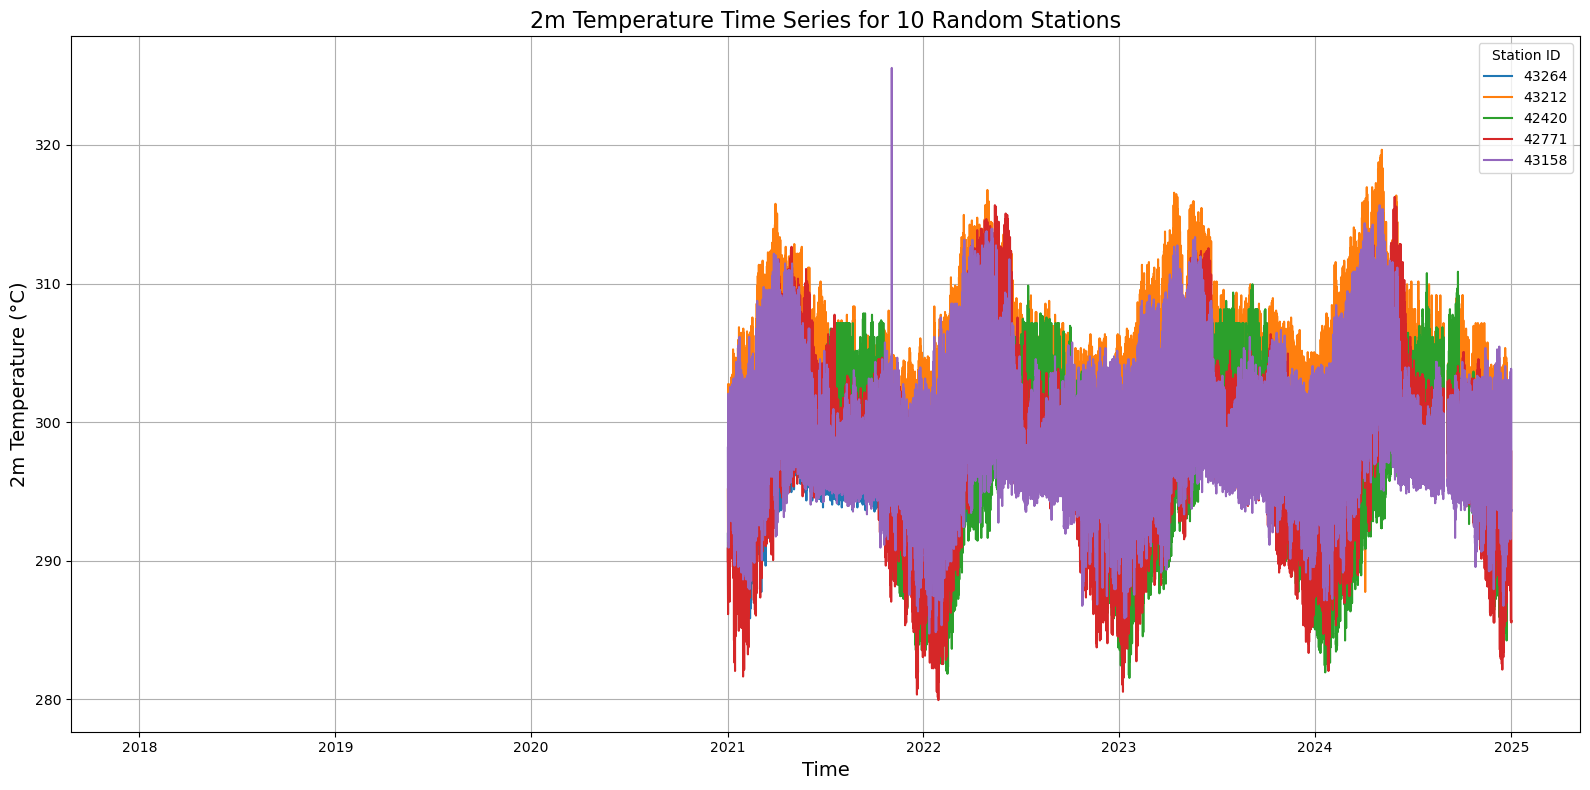

In [4]:
has_data = (~india_stations['2m_temperature'].isnull()).any(dim='time').compute()

# Get the list of stations that have valid data
valid_station_iindia_stations = india_stations.station_id.values[has_data.values]

# Step 2: Randomly pick 10 stations
random_stations = np.random.choice(valid_station_iindia_stations, size=5, replace=False)
# random_stations = valid_station_iindia_stations

# print("Randomly selected stations:", random_stations)

# Step 3: Subset the dataset for these 10 stations
subset = india_stations['2m_temperature'].sel(station_id=random_stations)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(16, 8))

# Loop over each station and plot
for i, station in tqdm(enumerate(random_stations)):
    temperature_series = subset.sel(station_id=station)
    ax.plot(india_stations['time'].values, temperature_series.values, label=str(station))

# Beautify the plot
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('2m Temperature (°C)', fontsize=14)
ax.set_title('2m Temperature Time Series for 10 Random Stations', fontsize=16)
ax.legend(title='Station ID', loc='upper right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('./stationbench_india_2m_temperature.png', dpi=300)

In [6]:
# Copyright 2024 Crown in Right of Canada
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS-IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


import matplotlib.pyplot as plt
import pandas as pd  

from tqdm import tqdm
import logging
import datetime

# Ideally, these environment variables should be set at the command-line, before
# even launching the script.  Results seem inconsistent when the environment variables
# are set via os.
if ('TF_FORCE_UNIFIED_MEMORY' not in os.environ.keys()):
    os.environ['TF_FORCE_UNIFIED_MEMORY']='1'
if ('XLA_CLIENT_MEM_FRACTION' not in os.environ.keys()):
    os.environ['XLA_CLIENT_MEM_FRACTION'] = '5.0'
# import multiprocessing as mp




def plot_training_metrics(losses, dates):

    print("Plotting training metrics...")
    """
    Plots
      1) training loss vs iteration
      2) histogram of which dates were sampled in each batch
    """
    # --- Plot 1: training loss curve ---
    plt.figure()
    plt.plot(losses, marker='o')
    plt.xlabel('Sample index')
    plt.ylabel('Loss')
    plt.title('Training Loss over Iterations')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('training_loss_curve.png')

    # --- Plot 2: date distribution ---
    plt.figure()
    dates = pd.to_datetime(dates)
    plt.hist(dates, bins=20)
    plt.xlabel('Initialization Date')
    plt.ylabel('Count')
    plt.title('Distribution of Batch Initialization Dates')
    plt.gcf().autofmt_xdate()   # rotate date labels
    plt.tight_layout()
    plt.savefig('date_distribution.png')





def print_memory_stats(gc_tracked = [0]):
    import jax
    
    print('Memory stats:')
    nowbytes = 0
    peakbytes = 0
    for dev in range(len(jax.local_devices())):
        mstat = jax.local_devices()[dev].memory_stats()
        if (mstat is not None): # Returns none on CPU
            nowbytes += mstat['bytes_in_use']
            peakbytes += mstat['peak_bytes_in_use']
        # print(f'Device {dev}: {jax.local_devices()[dev].memory_stats()}')
    asizes = [a.nbytes for a in jax.live_arrays()]
    import gc
    print(f'   {nowbytes / 1024 / 1024 / 1024 :.2f}GiB GPU memory in use, {peakbytes / 1024 / 1024 / 1024 :.2f}GiB peak',
            f'{len(asizes)} live Jax arrays of total size {sum(asizes)/1024/1024/1024:.2f}GiB',
            flush=True,end='')
    gc_tracked_now = len(gc.get_objects())
    print(f' {gc_tracked_now} Python objects, ({gc_tracked_now - gc_tracked[0]:+d})',flush=True,end='')
    print('',flush=True)
    gc_tracked[0] = gc_tracked_now

    
def wrap_dataset(ds,device):
    import graphcast.xarray_jax
    import jax
    return (graphcast.xarray_jax.Dataset(coords=ds.coords,
                                        data_vars = {k : (ds[k].dims,jax.device_put(graphcast.xarray_jax.unwrap_data(ds[k]),device=device)) for k in ds.data_vars}))


# Testing: locking JIT to a single thread may hurt performance with >2 GPUs
import threading
jit_lock = threading.Lock()
import collections
grad_jitted = collections.defaultdict(lambda : False)

def split_grad(idate,inputs,forcings_list,targets_list,grad_fn,grad_weight,predictor,dask_client):
    # Compute a combined gradient based on split but sequential inputs
    # forcings_list and targets_list are lists of xarrays.  The first entry in these lists
    # must be realized, but the subesequent entires need not be.  This function will use
    # dask_client to compute (load) the data during the gradient and IC calculation.
    import datetime
    import jax
    import datetime
    import contextlib
    global gpu_queue
    global grad_jitted
    global debug_prints
    (params_gpu, grad_accum_gpu, device) = gpu_queue.get()
    tic = datetime.datetime.now()
    
    total_lead_time = sum(t.time.size for t in targets_list)
    loss_accum = 0
    
    inputs_now = wrap_dataset(inputs,device)

    assert(len(targets_list) == len(forcings_list))
    assert(len(targets_list) > 0)

    # Get forcings and targets from the queue, and move them to the GPU
    targets_now = wrap_dataset(targets_list.pop(0),device)
    forcings_now = wrap_dataset(forcings_list.pop(0),device)

    grad_count = 1
    
    while True:
        this_lead = targets_now.time.size
        if (debug_prints):
            dtic1 = datetime.datetime.now()
            print(f'Computing gradient of {stamp(idate)} on {device}, stage {grad_count} for {this_lead} steps')
        if (len(targets_list) > 0):
            # If there are targets left, we'll be continuing the computation
            continue_computation = True
            # In the background, commence loading the next bunch of target/forcing data
            (targets_future,forcings_future) = dask_client.compute((targets_list.pop(0),forcings_list.pop(0)),sync=False)
        else:
            continue_computation = False

        # Compute the gradient over this segment
        with (jit_lock if not grad_jitted[(device,this_lead)] else contextlib.nullcontext()) as _:
            if (debug_prints):
                dtic2 = datetime.datetime.now()
                if ((dtic2-dtic1).total_seconds() > 1):
                    print(f'Commencing gradient computation on {device}, waited {(dtic2-dtic1).total_seconds():.2f}s for compilation lock')
                else: dtic2=dtic1
            (loss_now, _, grad_now) = grad_fn(inputs=inputs_now,forcings=forcings_now,targets = targets_now,params=params_gpu)
            grad_jitted[(device,this_lead)] = True
        # print(f'size {targets_now.time.size} in {(toc-tic).total_seconds():.2f}s')

        # Add the loss and gradient to their accumulators
        
        if (debug_prints):
            dtic3 = datetime.datetime.now()
            print(f'Accumulating gradient on {device} (+{(dtic3-dtic2).total_seconds():.2f}s)')
        loss_accum += loss_now*(targets_now.time.size/total_lead_time)
        grad_accum_gpu = grad_accumulate_jit(grad_now,grad_accum_gpu,grad_weight*this_lead/total_lead_time)        
        if (debug_prints):
            dtic4 = datetime.datetime.now()
            print(f'Gradient accumulated on {device} (+{(dtic4-dtic3).total_seconds():.2f}s)')

        if (continue_computation):
            grad_count += 1
            # Generate the next set of ICs
            inputs_now = future_ics(predictor=predictor,inputs=inputs_now,forcings=forcings_now,targets=targets_now,
                                    params=params_gpu,lead=targets_now.time.size)
            if (debug_prints):
                dtic5 = datetime.datetime.now()
                print(f'New ICs generated on {device} (+{(dtic5-dtic4).total_seconds():.2f}s)')
            # And realize the loading of the next target/forcing data.
            targets_now = wrap_dataset(targets_future.result(),device)
            forcings_now = wrap_dataset(forcings_future.result(),device)
            if (debug_prints):
                dtic6 = datetime.datetime.now()
                print(f'Next targets loaded on {device} (+{(dtic6-dtic5).total_seconds():.2f}s)')
                dtic_last = dtic6
        else:
            if (debug_prints):
                dtic_last=dtic4
            break

        
    gpu_queue.put( (params_gpu, grad_accum_gpu, device) )
    # Uncomment to block this call until the gradient accumulation is completed.
    # With this call commented out, timings may be inaccurate because Jax might return speculatively
    # while commputation is still happening on the GPU; the measured timings might be a better reflection
    # of how long it took to compute the _last_ gradient rather than the current one. 

    # With the call uncommented, timings will be more accurate, but the blocking will eliminate real
    # opportunities to overlap computation with other work, potentially causing a small slowdown.
    
    # next(iter(next(iter(grad_accum_gpu.values())).values())).block_until_ready()
    toc = datetime.datetime.now()
    if (debug_prints):
        print(f'Finished on {device}, {(toc-tic).total_seconds():.2f}s (+{(toc-dtic_last).total_seconds():.2f}s)')
    return (idate, loss_accum, (toc-tic).total_seconds())


def split_futures(futures):
    # Utility function to split a set of (dask) Futures into a done and not-done set
    done = []
    not_done = []
    for f in futures:
        if (f.done()):
            done.append(f)
        else:
            not_done.append(f)
    return(done,not_done)
    
def stamp(idate):
    # Helper function to return a YYYY-MM-DDTHH datetamp given
    # a datetime object
    return(idate.strftime('%Y-%m-%dT%H'))

def zero_grad_like(grad):
    '''Compute a tree structure of all zeros, matching the composition of an input
    structure – intended to initialize gradient updates given a sample gradient'''
    import tree
    return tree.map_structure(lambda gr: 0*gr, grad)

def grad_accumulate(grad,accum,weight):
    '''Return accum + weight*grad, intended to accumulate gradients over several independent
    examples of a batch'''
    import tree
    # Accumulate the gradient
    if (accum is None):
        if (weight == 1.0):
            return grad
        else:
            return tree.map_structure(lambda gr: gr*weight,grad)
    return tree.map_structure(lambda gr, acc : acc + gr*weight, grad, accum)


def consolidate_grad():
    # Consolidate accumulated gradients between GPU devices
    import jax
    global gpu_queue
    global params_device
    global grad_accumulate_jit
    accum_grad = None
    for idx in range(len(jax.devices('gpu'))):
        (params, grad, device) = gpu_queue.get(timeout=2)
        grad = jax.device_put(grad,params_device)
        if (accum_grad is None):
            accum_grad = grad
        else:
            accum_grad = grad_accumulate_jit(grad,accum_grad,1.0)
    assert(gpu_queue.empty())
    return accum_grad

def scatter_params(params):
    # Scatter the parameters to each GPU device, posting the paramters
    # and an initialized (zero) gradient accumulator to the device queue
    global gpu_queue
    import jax
    import trainer.grad_utils
    for device in jax.devices('gpu'):
        # print(f'Scattering parameters to {device=}')
        params_gpu = jax.device_put(params,device)
        accum_gpu = trainer.grad_utils.zero_grad_like(params_gpu)
        gpu_queue.put( (params_gpu, accum_gpu, device) )

def params_update(optimizer,accum_grad,opt_state,params):
    # Use a provided optax updater to update paramters, returning
    # the new paramters and the updated optimizer state
    import optax
    # print('Applying optimizer update')
    updates, opt_state = optimizer.update(accum_grad,opt_state,params)
    params = optax.apply_updates(params,updates)
    # print('... done')
    return(params,opt_state)

def write_checkpoint(path_schema,batch_number,params,model_config,task_config):
    checkpoint_filename = path_schema.format(batchnum = batch_number)
    with open(checkpoint_filename,'wb') as cfile:
        from graphcast import checkpoint
        import graphcast
        checkpoint.dump(cfile,graphcast.graphcast.CheckPoint(params=params,
                                                            model_config=model_config,
                                                            task_config=task_config,
                                                            description=f'Model checkpoint batch {batch_number}',license=""))
        
def write_opt_checkpoint(path_schema,batch_number,opt_state):
    opt_checkpoint_filename = path_schema.format(batchnum = batch_number) + '.opt'
    with open(opt_checkpoint_filename,'wb') as cfile:
        import pickle
        pickle.dump(opt_state,cfile,-1)

device_target_template = collections.defaultdict(lambda : None)
import jax
@jax.jit
def slice_ds(in_ds,idx):
    import jax.numpy as jnp
    
    import graphcast.xarray_jax
    coords = dict(in_ds.coords)
    coords['time'] = coords['time'][:1]
    data_vars = {}
    for v in in_ds.data_vars:
        if 'time' in in_ds[v].dims:
            data_vars[v] = (in_ds[v].dims,in_ds[v].data.jax_array[:,[idx,],...])
        else:
            data_vars[v] = (in_ds[v].dims,in_ds[v].data.jax_array)
    return graphcast.xarray_jax.Dataset(coords=coords,data_vars=data_vars)

@jax.jit
def stack_inputs(old_input,pred,forcings):
    global input_from_target
    global input_from_forcing
    inputs_next = pred[input_from_target]
    inputs_next[input_from_forcing] = forcings[input_from_forcing]
    for v in inputs_next.data_vars:
        inputs_next[v] = inputs_next[v].transpose(*old_input[v].dims)
    outputs = xr.concat((old_input.isel(time=[1,]),inputs_next),dim='time',coords='minimal',data_vars='minimal')
    outputs['time'] = old_input['time']
    return outputs

def future_ics(predictor,inputs,forcings,targets,params,lead):
    '''Given a predictor function, generate a set of Graphcast-compatible initial conditions
    by taking a basic input and integrating it over a given period, determined by the conventional
    forcings and targets arguments'''
    import xarray as xr
    import datetime
    global debug_prints
    params_device = list(list(list(params.values())[0].values())[0].devices())[0]
    # print(f'Computing ICs {params_device}')
    tic = datetime.datetime.now()
    # Advancing one step at a time, construct initial conditions valid at +lead*6h
    if (device_target_template[params_device] is None):
        device_target_template[params_device] = targets.isel(time=[0,]).copy(deep=True)
        # print(f'Creating target template for {params_device}, loaded on {device_target_template[params_device].geopotential.data.jax_array.device()}')
    targets_template = device_target_template[params_device]
    toc = datetime.datetime.now()
    # print(f'IC setup device {params_device} target template in {(toc-tic).total_seconds():.2f}s')
    tic=toc
    for it in range(lead):
        # forcings_now = forcings.isel(time=[it,])
        # forcings_now['time'] = targets_template['time']
        forcings_now = slice_ds(forcings,it)
        toc = datetime.datetime.now()
        # print(f'IC iter {it} device {params_device} forcings {(toc-tic).total_seconds():.2f}')
        tic=toc
        pred = predictor(inputs=inputs,forcings=forcings_now,targets=targets_template,params=params)
        pred.geopotential.data.jax_array.block_until_ready()
        toc = datetime.datetime.now()
        # print(f'IC iter {it} device {params_device} prediction {(toc-tic).total_seconds():.2f}')
        tic=toc

        inputs = stack_inputs(inputs,pred,forcings_now)
        toc=datetime.datetime.now()
        # print(f'IC iter {it} device {params_device} inputs_next {(toc-tic).total_seconds():.2f}')
        tic=toc
    return inputs

def data_split(targets,forcings,sizes):
    '''Given targets and forcings variables, split them into a disjoint set specified by
    the sizes parameter.  Rewrite the 'time' variable of each such that the resulting variables
    all begin at +6h.'''
    import numpy as np
    out_targets = []
    out_forcings = []
    assert(sum(sizes) == targets.time.size)
    assert(all(s >= 0 for s in sizes))
    for s in sizes:
        if (s == 0): continue
        t = targets.isel(time=slice(0,s))
        f = forcings.isel(time=slice(0,s))
        t['time'] = t['time'] - t['time'][0] + np.timedelta64(6,'h')
        f['time'] = f['time'] - f['time'][0] + np.timedelta64(6,'h')
        out_targets.append(t)
        out_forcings.append(f)

        targets = targets.isel(time=slice(s,None))
        forcings = forcings.isel(time=slice(s,None))
    return (out_targets,out_forcings)


def print_memory_stats(gc_tracked = [0]):
    import jax
    
    print('Memory stats:')
    nowbytes = 0
    peakbytes = 0
    for dev in range(len(jax.local_devices())):
        mstat = jax.local_devices()[dev].memory_stats()
        if (mstat is not None): # Returns none on CPU
            nowbytes += mstat['bytes_in_use']
            peakbytes += mstat['peak_bytes_in_use']
        # print(f'Device {dev}: {jax.local_devices()[dev].memory_stats()}')
    asizes = [a.nbytes for a in jax.live_arrays()]
    import gc
    print(f'   {nowbytes / 1024 / 1024 / 1024 :.2f}GiB GPU memory in use, {peakbytes / 1024 / 1024 / 1024 :.2f}GiB peak')
    print(f'   {len(asizes)} live Jax arrays of total size {sum(asizes)/1024/1024/1024:.2f}GiB')
    gc_tracked_now = len(gc.get_objects())
    print(f'   {gc_tracked_now} Python objects ({gc_tracked_now - gc_tracked[0]:+d})',flush=True)
    # print('',flush=True)
    gc_tracked[0] = gc_tracked_now



In [7]:


current_date = datetime.datetime.now().strftime("%Y%m%d")

import argparse
global debug_prints

import xarray as xr
import numpy as np
import numcodecs
import trainer.dataloader
import forecast.encabulator
import dateparser
import jax
import trainer.grad_utils
import datetime
import dask
import dask.distributed
import time
import sys


model_config = {}
model_config['resolution'] = 1.0

task_config = {}
# task_config['input_variables'] = ['geopotential','temperature','specific_humidity','u_component_of_wind','v_component_of_wind']

apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_1deg"
print(f'Using analysis database contained in {apath}')
dbase,_ = trainer.dataloader.open_databases(apath,None) # Note no need for a separate verification dbase
dbase


ModuleNotFoundError: No module named 'trainer'